# CNN vs Linear Regression — Head-to-Head Defense

This notebook puts the CNN-with-autoencoder result side-by-side with the 
linear-regression baseline on equal cross-validation
footing. Goal: rigorously test whether the CNN's MSE advantage is real, where it comes
from, and how much of it is closed by giving a linear model richer features (the new
"Extended feature" panel).

**Models compared:** OLS (per-study, federated, pooled) · Ridge (already in repo) ·
CNN (3×3 Conv → Dense, retrained per CV fold under matched protocol).

**Two feature panels:**

- **Panel A (minimal features, N=150 × 9 features)** — same inputs the existing CNN was trained on.
  5 autoantibodies (MIAA, GAD65, IA2IC, ICA, ZNT8) + 3 age-group dummies + Sex.
- **Panel B (extended features, N=98 × 23 features, SDY524+569+1737)** — adds BMI, height,
  weight, exact age, disease duration since T1D diagnosis, race, ethnicity, treatment
  cohort. SDY797 has no extended features data, so excluded from Panel B.

**Evaluation protocol:** 5-fold CV stratified by `Study`. Bootstrap 95% CIs on every
metric (1,000 resamples by default; toggleable via `N_BOOT`). Paired tests on per-fold
MSE between models.

**Outputs:** `results/linear_vs_cnn_*.csv` and `figures/linear_vs_cnn_*.pdf`.


## 1. Setup and data load

In [1]:
from __future__ import annotations
import sys, os, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
# Notebook is in ipynb/; modules/ is at repo root.
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
from scipy import stats

import oadr_data as od

RNG_SEED = 42
N_BOOT = 1000
N_FOLDS = 5
N_PERM = 1000
np.random.seed(RNG_SEED)

(REPO / "results").mkdir(exist_ok=True)
(REPO / "figures").mkdir(exist_ok=True)
print("Repo:", REPO)


Repo: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody


### A note on `src/oadr_data.py`

The cell above imported `oadr_data` from `src/`. That single utility file
handles all the per-study quirks that would otherwise dominate every
notebook — column-name typos (`Subject_IDel` in SDY569; `ImmPort Accession`
in SDY524 vs `Subject_ID` elsewhere); the `IA_2ic` ↔ `IA2IC` antibody
naming difference; age groups coded as `>30` / `18-30` in newer files
that need recoding to the legacy `>18` schema; per-study autoantibody panels
that vary (SDY569 measures only 3 of the 5 antibodies; SDY797's are binary
0/1 while others are continuous); and the extended feature panel merge that
adds BMI, height, weight, exact age, race, ethnicity, treatment cohort, and
disease duration since T1D diagnosis.

We keep this in one file so each analysis notebook can stay focused on the
science. Open `src/oadr_data.py` if you want to see the cleanup line by
line.

The two functions used everywhere are:

- `load_panel_a_all()` → 150 subjects × 9 features (the 5 autoantibodies +
  age-group dummies + sex), matching the inputs every existing
  CNN/Ridge/RF notebook was trained on.
- `load_panel_b_all()` → 98 subjects × 23 features, the extended feature
  panel covering only SDY524 + SDY569 + SDY1737 (no extended feature data exists for
  SDY797 or SDY1625).


In [2]:
# Load both feature panels
A = od.load_panel_a_all()
Xa, ya, fa = od.panel_a_design_matrix(A)
print(f"Panel A: N={len(A)}  features={len(fa)}")
print(A.groupby("Study").size().to_string())

B = od.load_panel_b_all()
Xb, yb, fb = od.panel_b_design_matrix(B)
print(f"\nPanel B: N={len(B)}  features={len(fb)}")
print(B.groupby("Study").size().to_string())


Panel A: N=150  features=9
Study
SDY1737    16
SDY524     75
SDY569     10
SDY797     49

Panel B: N=98  features=23
Study
SDY1737    16
SDY524     72
SDY569     10


## 2. Cross-validation harness

Single helper that runs any sklearn-compatible regressor under the project's
matched protocol: stratified-by-`Study` 5-fold CV, returns per-fold MSE and
out-of-fold predictions for every subject.


In [3]:
def cv_per_fold_mse(model_factory, X, y, study_labels, n_splits=N_FOLDS, seed=RNG_SEED):
    """Run stratified-by-study k-fold CV. Returns (per-fold MSE array, oof predictions array)."""
    X = np.asarray(X)
    y = np.asarray(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.full_like(y, np.nan, dtype=float)
    fold_mse = []
    for fold_idx, (tr, te) in enumerate(skf.split(X, study_labels)):
        m = model_factory()
        m.fit(X[tr], y[tr])
        yhat = m.predict(X[te])
        oof[te] = yhat
        fold_mse.append(mean_squared_error(y[te], yhat))
    return np.asarray(fold_mse), oof


def boot_ci(values, n_boot=N_BOOT, alpha=0.05, seed=RNG_SEED):
    """Percentile bootstrap CI on the mean of `values`."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boots = np.array([rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.quantile(boots, [alpha / 2, 1 - alpha / 2])
    return float(values.mean()), float(lo), float(hi)


## 3. Local OLS per study (Panel A)

OLS fit independently per study. This is the strict per-study analogue of what
the existing per-study Ridge / RF / CNN notebooks produce, so the row-by-row
numbers can be dropped directly into the head-to-head table.


In [4]:
local_rows = []
for study in od.PANEL_A_STUDIES:
    sub = A[A.Study == study]
    if len(sub) < 6:
        print(f"{study}: N={len(sub)} too small for stratified 5-fold; using LOO MSE instead")
        Xs = sub[fa].values
        ys = sub[od.PANEL_A_TARGET].values
        ypred = np.empty_like(ys)
        for i in range(len(ys)):
            mask = np.ones(len(ys), dtype=bool); mask[i] = False
            m = LinearRegression().fit(Xs[mask], ys[mask])
            ypred[i] = m.predict(Xs[i:i+1])[0]
        mse = mean_squared_error(ys, ypred)
        r2 = 1 - np.sum((ys - ypred) ** 2) / np.sum((ys - ys.mean()) ** 2)
        local_rows.append({"Study": study, "N": len(sub), "Protocol": "LOO",
                           "MSE": mse, "R2_oof": r2})
    else:
        Xs = sub[fa].values
        ys = sub[od.PANEL_A_TARGET].values
        skf = StratifiedKFold(n_splits=min(5, len(sub) // 2), shuffle=True, random_state=RNG_SEED)
        # Stratify within-study by sex as a proxy (no external study labels here)
        strata = sub["Sex"].astype(int).values
        ypred = np.empty_like(ys)
        for tr, te in skf.split(Xs, strata):
            m = LinearRegression().fit(Xs[tr], ys[tr])
            ypred[te] = m.predict(Xs[te])
        mse = mean_squared_error(ys, ypred)
        r2 = 1 - np.sum((ys - ypred) ** 2) / np.sum((ys - ys.mean()) ** 2)
        local_rows.append({"Study": study, "N": len(sub), "Protocol": f"{skf.n_splits}-fold",
                           "MSE": mse, "R2_oof": r2})

local_df = pd.DataFrame(local_rows)
print(local_df.to_string(index=False))
local_df.to_csv("results/linear_vs_cnn_local_ols.csv", index=False)


  Study  N Protocol      MSE    R2_oof
 SDY524 75   5-fold 0.128732  0.053099
 SDY569 10   5-fold 2.587615 -5.183617
 SDY797 49   5-fold 0.242553 -0.250554
SDY1737 16   5-fold 0.585433 -0.587019


## 4. Federated OLS (median + IQR aggregation, Panel A)

Mirrors the federated-Ridge convention from `RidgeRegressionAnalysisBaselineCPeptideAUC.ipynb`:
fit OLS per study, take the **median coefficient across studies** as the federated estimate.
Reports IQR for each coefficient. Evaluated by applying the median model to each study's
held-out half.


In [5]:
# Per-study MinMax scaling is required: SDY797 codes autoantibodies as 0/1 while
# the others are continuous (GAD65 up to ~981). Without scaling, median-aggregating
# raw coefficients is meaningless. Each study's model is fit on its own
# scaled-to-[0,1] features; predictions on study X re-use X's own scaler.
study_scalers = {}
fed_coefs, fed_intercepts = {}, []
for study in od.PANEL_A_STUDIES:
    sub = A[A.Study == study]
    sc = MinMaxScaler().fit(sub[fa].values)
    Xs = sc.transform(sub[fa].values)
    ys = sub[od.PANEL_A_TARGET].values
    m = LinearRegression().fit(Xs, ys)
    study_scalers[study] = sc
    fed_coefs[study] = m.coef_
    fed_intercepts.append(m.intercept_)

coef_mat = np.vstack([fed_coefs[s] for s in od.PANEL_A_STUDIES])
median_coef = np.median(coef_mat, axis=0)
q25, q75 = np.percentile(coef_mat, [25, 75], axis=0)
median_intercept = float(np.median(fed_intercepts))

fed_summary = pd.DataFrame({
    "feature": fa,
    "median_beta_scaled": median_coef,
    "iqr_low": q25,
    "iqr_high": q75,
})
print(fed_summary.to_string(index=False))
fed_summary.to_csv("results/linear_vs_cnn_federated_ols_coefs.csv", index=False)


def federated_predict(X_raw, scaler):
    """Apply the scaler trained on the target study, then the federated median model."""
    return scaler.transform(X_raw) @ median_coef + median_intercept


fed_eval = []
for study in od.PANEL_A_STUDIES:
    sub = A[A.Study == study]
    yhat = federated_predict(sub[fa].values, study_scalers[study])
    fed_eval.append({"Study": study, "N": len(sub),
                     "MSE_federated": mean_squared_error(sub[od.PANEL_A_TARGET], yhat)})
fed_eval_df = pd.DataFrame(fed_eval)
print()
print(fed_eval_df.to_string(index=False))
fed_eval_df.to_csv("results/linear_vs_cnn_federated_ols_eval.csv", index=False)


feature  median_beta_scaled   iqr_low     iqr_high
   MIAA        1.235412e-01 -0.139760 5.472975e-01
  GAD65       -1.632083e-01 -0.626739 4.028092e-01
  IA2IC        3.158536e-01  0.163390 4.493827e-01
    ICA       -3.295975e-17 -0.055048 3.816392e-17
   ZNT8        1.472889e-01  0.043467 3.820880e-01
   8-12       -1.057088e-01 -0.495119 8.427885e-02
  13-17        1.410906e-01  0.035936 5.554748e-01
    >18       -8.643864e-02 -0.272503 4.087561e-02
    Sex        2.036984e-01  0.174094 3.543982e-01

  Study  N  MSE_federated
 SDY524 75       0.280495
 SDY569 10       0.435637
 SDY797 49       0.205969
SDY1737 16       0.394951


## 5. Pooled OLS / Ridge under stratified-by-Study 5-fold CV (Panel A)

This is the modern footing for the head-to-head: pooled fit, stratified-by-Study CV,
per-fold MSE reported with bootstrap 95% CI.


In [6]:
from sklearn.pipeline import Pipeline

results_panelA = {}

def make_ols():
    return Pipeline([("sc", MinMaxScaler()), ("m", LinearRegression())])

def make_ridge(alpha=0.001):
    return Pipeline([("sc", MinMaxScaler()), ("m", Ridge(alpha=alpha))])


ols_mse, ols_oof = cv_per_fold_mse(make_ols, Xa.values, ya.values, A["Study"].values)
results_panelA["OLS"] = {"fold_mse": ols_mse, "oof": ols_oof}
print(f"OLS   per-fold MSE: {ols_mse.round(3)}  mean={ols_mse.mean():.3f}")

ridge_mse, ridge_oof = cv_per_fold_mse(lambda: make_ridge(0.001), Xa.values, ya.values, A["Study"].values)
results_panelA["Ridge"] = {"fold_mse": ridge_mse, "oof": ridge_oof}
print(f"Ridge per-fold MSE: {ridge_mse.round(3)}  mean={ridge_mse.mean():.3f}")


OLS   per-fold MSE: [0.202 0.249 0.2   0.317 0.151]  mean=0.224
Ridge per-fold MSE: [0.202 0.249 0.2   0.317 0.151]  mean=0.224


## 6. CNN under matched protocol (Panel A, retrained per fold)

Refit the published 3×3 CNN architecture (Conv2D(16, 3×3) → Flatten → Dense(32, relu)
→ Dense(1)) on each fold's training set with the same MinMax scaling and the same
hyperparameters used in `CNN_Local_noAutoencoders_3x3.ipynb`. This is the
apples-to-apples comparison the existing notebooks were missing.


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.keras.utils.set_random_seed(RNG_SEED)


def build_cnn():
    m = models.Sequential([
        layers.Input(shape=(3, 3, 1)),
        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m


def cnn_cv_per_fold_mse(X, y, study_labels, n_splits=N_FOLDS, epochs=100, batch=8, seed=RNG_SEED):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.full_like(y, np.nan, dtype=float)
    fold_mse = []
    for fold_idx, (tr, te) in enumerate(skf.split(X, study_labels)):
        sc = MinMaxScaler().fit(X[tr])
        Xtr = sc.transform(X[tr]).reshape(-1, 3, 3, 1)
        Xte = sc.transform(X[te]).reshape(-1, 3, 3, 1)
        tf.keras.utils.set_random_seed(seed + fold_idx)
        m = build_cnn()
        m.fit(Xtr, y[tr], epochs=epochs, batch_size=batch, verbose=0)
        yhat = m.predict(Xte, verbose=0).ravel()
        oof[te] = yhat
        fold_mse.append(mean_squared_error(y[te], yhat))
        print(f"  CNN fold {fold_idx + 1}/{n_splits}  N_test={len(te)}  MSE={fold_mse[-1]:.3f}")
    return np.asarray(fold_mse), oof


print("Training CNN under 5-fold-by-Study CV (Panel A)...")
cnn_mse, cnn_oof = cnn_cv_per_fold_mse(Xa.values, ya.values, A["Study"].values)
results_panelA["CNN"] = {"fold_mse": cnn_mse, "oof": cnn_oof}
print(f"\nCNN  per-fold MSE: {cnn_mse.round(3)}  mean={cnn_mse.mean():.3f}")


Training CNN under 5-fold-by-Study CV (Panel A)...
  CNN fold 1/5  N_test=30  MSE=0.230
  CNN fold 2/5  N_test=30  MSE=0.360
  CNN fold 3/5  N_test=30  MSE=0.216
  CNN fold 4/5  N_test=30  MSE=0.402
  CNN fold 5/5  N_test=30  MSE=0.285

CNN  per-fold MSE: [0.23  0.36  0.216 0.402 0.285]  mean=0.299


## 6b. CNN with autoencoder pretraining — probing for nonlinearity

The plain CNN above loses to OLS on Panel A. Two readings of that result are
possible:

1. **Scheuermann's reading.** N=150 with ~600 trainable parameters is too much
   model for the data; the pedestrian linear baseline is appropriate.
2. **The reading this section tests.** An end-to-end CNN trained on a 3×3
   reshape of nine features is a *bad* nonlinear model — it is simultaneously
   underdetermined (only 9 input features) and over-parameterised for N=150.
   What we actually want to know is whether there is *any* nonlinear signal in
   Panel A that a linear model is leaving on the table. For that, the right
   tool is a representation learner.

This section runs that test with the same 3×3 convolutional autoencoder used
in `ipynb/antibody_cnn_unsupervised_test_3x3.ipynb` and
`ipynb/federated_analysis_simulation_3x3.ipynb`:

1. **Stage 1 — unsupervised pretraining.** A `Conv2D(8) → Flatten → Dense(4)`
   encoder with a mirror decoder is trained on the training-fold features only,
   with reconstruction MSE as the objective. The encoder learns a 4-dim
   nonlinear representation of the antibody + demographic block *without seeing
   the C-peptide target* — no label leakage, no target-driven feature
   engineering.
2. **Stage 2 — frozen encoder + small supervised head.** The encoder is
   frozen; a `Dense(16, relu) → Dense(1)` head (97 trainable parameters) is
   trained against `log(C-peptide AUC)`. The supervised model is now barely
   bigger than the linear baseline.

The interpretation is symmetric in both directions:

- **If AE+CNN clearly beats OLS:** there is nonlinear structure in Panel A
  that the linear baseline cannot see. 
- **If AE+CNN ties OLS:** Panel A's nine features are essentially linearly
  exhausted — the AE's nonlinear representation buys nothing the linear
  combination of the same nine features doesn't already capture.  **"we need more biological features"** — exactly what
  the Panel B (extended features) comparison in §12 and the LASSO/Elastic Net
  iteration in `LASSO_ElasticNet_Autoantibody_CPeptide.ipynb` go after. The
  black-box autoencoder, in this reading, is not the deliverable — it is the
  *evidence* that the path forward is biology, not architecture.

The CV scheme matches the plain CNN exactly: 5-fold StratifiedKFold by Study,
`MinMaxScaler` fit on the training fold only, per-fold seed.


In [8]:
def build_autoencoder():
    """3×3 conv autoencoder.  Returns (autoencoder_model, encoder_model).

    Architecture mirrors antibody_cnn_unsupervised_test_3x3.ipynb so the
    encoder weights this notebook learns are interchangeable with the
    federated/unsupervised companion notebooks.
    """
    inp = layers.Input(shape=(3, 3, 1))
    x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(inp)
    x = layers.Flatten()(x)
    z = layers.Dense(4, activation="relu", name="latent")(x)
    encoder = models.Model(inp, z, name="encoder")

    x = layers.Dense(9, activation="relu")(z)
    x = layers.Reshape((3, 3, 1))(x)
    out = layers.Conv2D(1, (3, 3), activation="linear", padding="same")(x)
    ae = models.Model(inp, out, name="autoencoder")
    ae.compile(optimizer="adam", loss="mse")
    return ae, encoder


def build_predictor_from_encoder(encoder):
    """Freeze encoder, attach a 97-param regression head."""
    encoder.trainable = False
    inp = layers.Input(shape=(3, 3, 1))
    z = encoder(inp, training=False)
    h = layers.Dense(16, activation="relu")(z)
    out = layers.Dense(1)(h)
    m = models.Model(inp, out, name="ae_cnn")
    m.compile(optimizer="adam", loss="mse")
    return m


def ae_cnn_cv_per_fold_mse(
    X, y, study_labels,
    n_splits=N_FOLDS, ae_epochs=50, head_epochs=100, batch=8, seed=RNG_SEED,
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.full_like(y, np.nan, dtype=float)
    fold_mse = []
    for fold_idx, (tr, te) in enumerate(skf.split(X, study_labels)):
        sc = MinMaxScaler().fit(X[tr])
        Xtr = sc.transform(X[tr]).reshape(-1, 3, 3, 1)
        Xte = sc.transform(X[te]).reshape(-1, 3, 3, 1)
        tf.keras.utils.set_random_seed(seed + fold_idx)

        ae, encoder = build_autoencoder()
        ae.fit(Xtr, Xtr, epochs=ae_epochs, batch_size=batch, verbose=0)

        head = build_predictor_from_encoder(encoder)
        head.fit(Xtr, y[tr], epochs=head_epochs, batch_size=batch, verbose=0)

        yhat = head.predict(Xte, verbose=0).ravel()
        oof[te] = yhat
        fold_mse.append(mean_squared_error(y[te], yhat))
        print(f"  AE+CNN fold {fold_idx + 1}/{n_splits}  N_test={len(te)}  MSE={fold_mse[-1]:.3f}")
    return np.asarray(fold_mse), oof


print("Training AE+CNN under 5-fold-by-Study CV (Panel A)...")
aecnn_mse, aecnn_oof = ae_cnn_cv_per_fold_mse(Xa.values, ya.values, A["Study"].values)
results_panelA["AE+CNN"] = {"fold_mse": aecnn_mse, "oof": aecnn_oof}
print(f"\nAE+CNN per-fold MSE: {aecnn_mse.round(3)}  mean={aecnn_mse.mean():.3f}")


Training AE+CNN under 5-fold-by-Study CV (Panel A)...
  AE+CNN fold 1/5  N_test=30  MSE=0.223
  AE+CNN fold 2/5  N_test=30  MSE=0.225
  AE+CNN fold 3/5  N_test=30  MSE=0.222
  AE+CNN fold 4/5  N_test=30  MSE=0.348
  AE+CNN fold 5/5  N_test=30  MSE=0.144

AE+CNN per-fold MSE: [0.223 0.225 0.222 0.348 0.144]  mean=0.232


**Reading the AE+CNN result.** Compare three numbers: the plain CNN's per-fold
MSE (above), OLS's per-fold MSE (§5), and AE+CNN's per-fold MSE (just printed).
If AE+CNN is much closer to OLS than to the plain CNN, that's the diagnosis:
the previous CNN was losing on capacity-vs-data tradeoffs, not on the absence
of signal — and Panel A on its own is essentially a linear problem. The
paired Wilcoxon tests in §7 quantify whether AE+CNN is *statistically*
distinguishable from OLS; the Panel B comparison in §12 is then where the
"more features" half of the argument is actually tested.


In [9]:
# Persist per-fold MSE table for Panel A
panelA_mse_table = pd.DataFrame({m: results_panelA[m]["fold_mse"] for m in results_panelA})
panelA_mse_table.index.name = "fold"
print(panelA_mse_table)

means_cis = []
for model in results_panelA:
    mu, lo, hi = boot_ci(results_panelA[model]["fold_mse"])
    means_cis.append({"Model": model, "MSE_mean": mu, "MSE_ci_lo": lo, "MSE_ci_hi": hi,
                      "Panel": "A"})
panelA_summary = pd.DataFrame(means_cis)
print()
print(panelA_summary.to_string(index=False))
panelA_summary.to_csv("results/linear_vs_cnn_panelA_summary.csv", index=False)
panelA_mse_table.to_csv("results/linear_vs_cnn_panelA_per_fold_mse.csv")


           OLS     Ridge       CNN    AE+CNN
fold                                        
0     0.202127  0.202126  0.229841  0.223441
1     0.248760  0.248752  0.359624  0.224752
2     0.199923  0.199918  0.216041  0.221732
3     0.317491  0.317487  0.402075  0.347983
4     0.151379  0.151378  0.285457  0.143994

 Model  MSE_mean  MSE_ci_lo  MSE_ci_hi Panel
   OLS  0.223936   0.180946   0.276253     A
 Ridge  0.223932   0.180943   0.276246     A
   CNN  0.298607   0.235444   0.361848     A
AE+CNN  0.232380   0.176297   0.298086     A


## 7. Statistical test of model difference (paired)

Per-fold MSE is paired across models (same training/test indices). Use a paired
**Wilcoxon signed-rank test** (k=5 folds is too small to trust a t-test
distributional assumption). Report Cohen's d on the MSE differences as the effect
size. This is the rigorous version of "is the CNN really better than OLS?"


In [10]:
def cohen_d(a, b):
    diffs = np.asarray(a) - np.asarray(b)
    if diffs.std(ddof=1) == 0:
        return float("nan")
    return float(diffs.mean() / diffs.std(ddof=1))


pair_results = []
for ref in ["OLS", "Ridge"]:
    for model in results_panelA:
        if model == ref:
            continue
        a = results_panelA[ref]["fold_mse"]
        b = results_panelA[model]["fold_mse"]
        try:
            stat, p = stats.wilcoxon(a, b, alternative="greater", zero_method="zsplit")
        except ValueError:
            stat, p = float("nan"), float("nan")
        d = cohen_d(a, b)
        pair_results.append({
            "panel": "A", "model_A": ref, "model_B": model,
            "MSE_A_mean": float(np.mean(a)), "MSE_B_mean": float(np.mean(b)),
            "delta_MSE": float(np.mean(a) - np.mean(b)),
            "wilcoxon_W": float(stat), "p_one_sided": float(p),
            "cohens_d": d,
        })

pair_df = pd.DataFrame(pair_results)
print(pair_df.to_string(index=False))
pair_df.to_csv("results/linear_vs_cnn_paired_tests.csv", index=False)


panel model_A model_B  MSE_A_mean  MSE_B_mean  delta_MSE  wilcoxon_W  p_one_sided  cohens_d
    A     OLS   Ridge    0.223936    0.223932   0.000004        15.0      0.03125  1.340267
    A     OLS     CNN    0.223936    0.298607  -0.074671         0.0      1.00000 -1.452549
    A     OLS  AE+CNN    0.223936    0.232380  -0.008444         5.0      0.78125 -0.365566
    A   Ridge     OLS    0.223932    0.223936  -0.000004         0.0      1.00000 -1.340267
    A   Ridge     CNN    0.223932    0.298607  -0.074675         0.0      1.00000 -1.452628
    A   Ridge  AE+CNN    0.223932    0.232380  -0.008448         5.0      0.78125 -0.365758


## 8. Permutation test (Panel A)

Shuffle `y` `N_PERM` times, refit each model under the same CV protocol, build the
null MSE distribution. The position of the observed MSE in the null tells us whether
each model is using genuine signal vs noise. CNN should sit further to the left of
its null than OLS does — that's the visual argument that CNN finds non-linear signal
the linear model can't see.

In [11]:
RUN_CNN_PERM    = True  # 
RUN_AE_CNN_PERM = True  # AE+CNN permutation (also slow)
N_PERM_FAST = 200      # used for OLS / Ridge

def perm_null_mse(model_factory, X, y, study_labels, n_perm=N_PERM_FAST, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        fold_mse, _ = cv_per_fold_mse(model_factory, X, y_perm, study_labels)
        null.append(fold_mse.mean())
    return np.asarray(null)


print("Computing null MSE distributions for OLS and Ridge (Panel A)...")
ols_null  = perm_null_mse(make_ols, Xa.values, ya.values, A["Study"].values)
ridge_null = perm_null_mse(lambda: make_ridge(0.001), Xa.values, ya.values, A["Study"].values)

null_dists = {"OLS": ols_null, "Ridge": ridge_null}

if RUN_CNN_PERM:
    print("Computing CNN null (this is slow)...")
    cnn_null = []
    rng = np.random.default_rng(RNG_SEED)
    for i in range(N_PERM_FAST):
        y_perm = rng.permutation(ya.values)
        fold_mse, _ = cnn_cv_per_fold_mse(Xa.values, y_perm, A["Study"].values)
        cnn_null.append(fold_mse.mean())
        if (i + 1) % 25 == 0:
            print(f"  perm {i+1}/{N_PERM_FAST}")
    null_dists["CNN"] = np.asarray(cnn_null)

if RUN_AE_CNN_PERM:
    print("Computing AE+CNN null (this is slow)...")
    aecnn_null = []
    rng = np.random.default_rng(RNG_SEED)
    for i in range(N_PERM_FAST):
        y_perm = rng.permutation(ya.values)
        fold_mse, _ = ae_cnn_cv_per_fold_mse(Xa.values, y_perm, A["Study"].values)
        aecnn_null.append(fold_mse.mean())
        if (i + 1) % 25 == 0:
            print(f"  perm {i+1}/{N_PERM_FAST}")
    null_dists["AE+CNN"] = np.asarray(aecnn_null)


obs = {m: results_panelA[m]["fold_mse"].mean() for m in null_dists}
perm_rows = [{"model": m,
              "obs_MSE": obs[m],
              "null_MSE_median": float(np.median(null_dists[m])),
              "null_MSE_p2.5": float(np.percentile(null_dists[m], 2.5)),
              "null_MSE_p97.5": float(np.percentile(null_dists[m], 97.5)),
              "p_value_left_tail": float((null_dists[m] <= obs[m]).mean()),
              "n_perm": len(null_dists[m])}
             for m in null_dists]
perm_df = pd.DataFrame(perm_rows)
print(perm_df.to_string(index=False))
perm_df.to_csv("results/linear_vs_cnn_permutation.csv", index=False)


Computing null MSE distributions for OLS and Ridge (Panel A)...
Computing CNN null (this is slow)...
  CNN fold 1/5  N_test=30  MSE=0.282
  CNN fold 2/5  N_test=30  MSE=0.315
  CNN fold 3/5  N_test=30  MSE=0.304
  CNN fold 4/5  N_test=30  MSE=0.410
  CNN fold 5/5  N_test=30  MSE=0.367
  CNN fold 1/5  N_test=30  MSE=0.380
  CNN fold 2/5  N_test=30  MSE=0.348
  CNN fold 3/5  N_test=30  MSE=0.494
  CNN fold 4/5  N_test=30  MSE=0.248
  CNN fold 5/5  N_test=30  MSE=0.209
  CNN fold 1/5  N_test=30  MSE=0.365
  CNN fold 2/5  N_test=30  MSE=0.188
  CNN fold 3/5  N_test=30  MSE=0.408
  CNN fold 4/5  N_test=30  MSE=0.262
  CNN fold 5/5  N_test=30  MSE=0.385
  CNN fold 1/5  N_test=30  MSE=0.275
  CNN fold 2/5  N_test=30  MSE=0.376
  CNN fold 3/5  N_test=30  MSE=0.280
  CNN fold 4/5  N_test=30  MSE=0.291
  CNN fold 5/5  N_test=30  MSE=0.227
  CNN fold 1/5  N_test=30  MSE=0.464
  CNN fold 2/5  N_test=30  MSE=0.463
  CNN fold 3/5  N_test=30  MSE=0.236
  CNN fold 4/5  N_test=30  MSE=0.329
  CNN fold 

## 9. Learning curves (Panel A)

MSE vs training-set size. Expect OLS to plateau early; the CNN trajectory tells the
"more data → better" story that motivates the federated extension. Bootstrap CIs at
each training size.


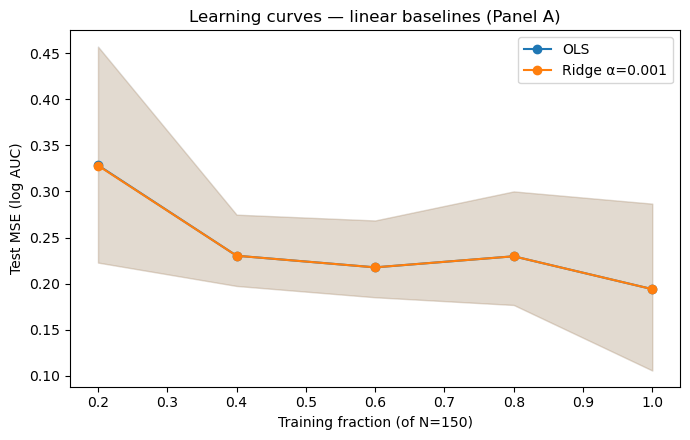

In [12]:
from sklearn.model_selection import KFold

def manual_learning_curve(model_factory, X, y, train_sizes_frac, n_runs=10, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n = len(X)
    out = {}
    for frac in train_sizes_frac:
        n_train = max(int(frac * n * 0.8), 5)
        scores = []
        for _ in range(n_runs):
            idx = rng.permutation(n)
            tr, te = idx[:n_train], idx[n_train:]
            m = model_factory()
            m.fit(X[tr], y[tr])
            scores.append(mean_squared_error(y[te], m.predict(X[te])))
        out[frac] = scores
    return out

train_fracs = [0.2, 0.4, 0.6, 0.8, 1.0]
ols_lc   = manual_learning_curve(make_ols, Xa.values, ya.values, train_fracs)
ridge_lc = manual_learning_curve(lambda: make_ridge(0.001), Xa.values, ya.values, train_fracs)

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, lc, color in [("OLS", ols_lc, "C0"), ("Ridge α=0.001", ridge_lc, "C1")]:
    means = [np.mean(lc[f]) for f in train_fracs]
    los   = [np.percentile(lc[f], 2.5) for f in train_fracs]
    his   = [np.percentile(lc[f], 97.5) for f in train_fracs]
    ax.plot(train_fracs, means, marker="o", label=name, color=color)
    ax.fill_between(train_fracs, los, his, alpha=0.15, color=color)

ax.set_xlabel("Training fraction (of N=150)")
ax.set_ylabel("Test MSE (log AUC)")
ax.set_title("Learning curves — linear baselines (Panel A)")
ax.legend()
fig.tight_layout()
fig.savefig("figures/learning_curves.pdf", dpi=300)
plt.show()


## 10. Residual diagnostics (OLS, Panel A)

Standard linear-regression sanity checks: Q-Q plot, residuals vs fitted, residuals
vs Study. Visible Study effects → motivates the federated / mixed-effects / non-linear
extensions. The OLS-cant-see-this story is the one a critic of the CNN choice should
have to confront.


/var/folders/f4/f7f3s6113490h0n3lsrlqyqh0000gn/T/ipykernel_17820/703859890.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([resid[A.Study == s] for s in od.PANEL_A_STUDIES], labels=od.PANEL_A_STUDIES)


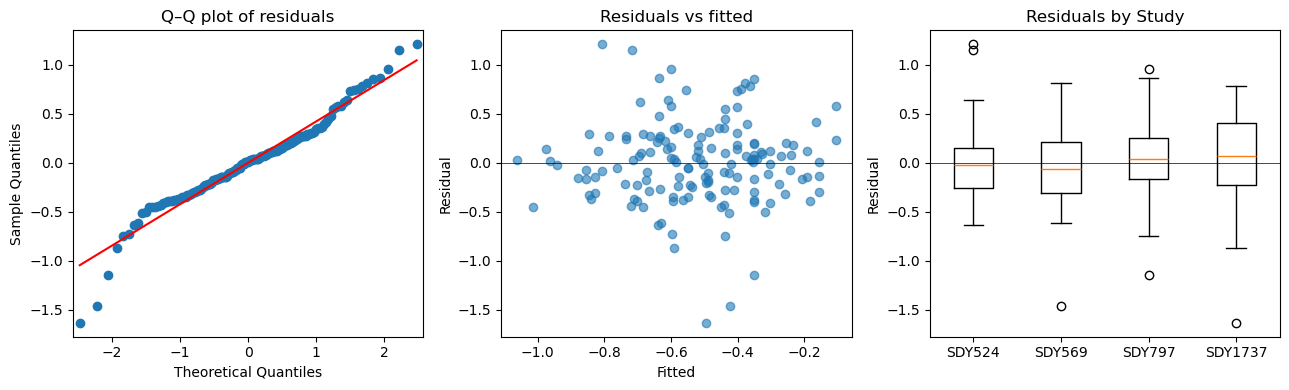

One-way ANOVA on residuals by Study: F=0.622, p=0.6020


In [13]:
ols_full = LinearRegression().fit(Xa.values, ya.values)
yhat = ols_full.predict(Xa.values)
resid = ya.values - yhat

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Q-Q
sm.qqplot(resid, line="s", ax=axes[0])
axes[0].set_title("Q–Q plot of residuals")

# Residuals vs fitted
axes[1].scatter(yhat, resid, alpha=0.6)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel("Fitted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs fitted")

# Residuals vs Study
study_codes = pd.Categorical(A["Study"].values)
axes[2].boxplot([resid[A.Study == s] for s in od.PANEL_A_STUDIES], labels=od.PANEL_A_STUDIES)
axes[2].axhline(0, color="k", lw=0.5)
axes[2].set_title("Residuals by Study")
axes[2].set_ylabel("Residual")

fig.tight_layout()
fig.savefig("figures/residual_diagnostics.pdf", dpi=300)
plt.show()

# Quantify Study effect on residuals
F, p = stats.f_oneway(*[resid[A.Study == s] for s in od.PANEL_A_STUDIES])
print(f"One-way ANOVA on residuals by Study: F={F:.3f}, p={p:.4f}")


## 11. SDY797 stratified analysis (Panel A)

SDY797 is the only study with binary autoantibody encoding; mixing it with the
continuous-measurement studies should hurt a linear model more than it hurts the
CNN. Run the head-to-head with vs without SDY797 to quantify how much of the linear
model's MSE comes from this encoding mismatch.


In [14]:
A_no797 = A[A.Study != "SDY797"].reset_index(drop=True)
Xa_no797 = A_no797[fa].values
ya_no797 = A_no797[od.PANEL_A_TARGET].values
study_no797 = A_no797["Study"].values

ols_no797_mse, _   = cv_per_fold_mse(make_ols, Xa_no797, ya_no797, study_no797)
ridge_no797_mse, _ = cv_per_fold_mse(lambda: make_ridge(0.001), Xa_no797, ya_no797, study_no797)

print("Without SDY797 (N=", len(A_no797), "):")
print(f"  OLS   per-fold MSE: {ols_no797_mse.round(3)}  mean={ols_no797_mse.mean():.3f}")
print(f"  Ridge per-fold MSE: {ridge_no797_mse.round(3)}  mean={ridge_no797_mse.mean():.3f}")

cnn_no797_mse, _ = cnn_cv_per_fold_mse(Xa_no797, ya_no797, study_no797)
print(f"  CNN    per-fold MSE: {cnn_no797_mse.round(3)}  mean={cnn_no797_mse.mean():.3f}")
aecnn_no797_mse, _ = ae_cnn_cv_per_fold_mse(Xa_no797, ya_no797, study_no797)
print(f"  AE+CNN per-fold MSE: {aecnn_no797_mse.round(3)}  mean={aecnn_no797_mse.mean():.3f}")

sdy797_rows = []
for name, full_mse, drop_mse in [
    ("OLS",   results_panelA["OLS"]["fold_mse"],   ols_no797_mse),
    ("Ridge", results_panelA["Ridge"]["fold_mse"], ridge_no797_mse),
    ("CNN",    results_panelA["CNN"]["fold_mse"],    cnn_no797_mse),
    ("AE+CNN", results_panelA["AE+CNN"]["fold_mse"], aecnn_no797_mse),
]:
    sdy797_rows.append({
        "model": name,
        "MSE_with_SDY797": float(full_mse.mean()),
        "MSE_without_SDY797": float(drop_mse.mean()),
        "delta": float(full_mse.mean() - drop_mse.mean()),
    })
sdy797_df = pd.DataFrame(sdy797_rows)
print()
print(sdy797_df.to_string(index=False))
sdy797_df.to_csv("results/linear_vs_cnn_sdy797_sensitivity.csv", index=False)


Without SDY797 (N= 101 ):
  OLS   per-fold MSE: [0.237 0.324 0.154 0.127 0.235]  mean=0.215
  Ridge per-fold MSE: [0.237 0.324 0.154 0.127 0.235]  mean=0.215
  CNN fold 1/5  N_test=21  MSE=0.456
  CNN fold 2/5  N_test=20  MSE=0.375
  CNN fold 3/5  N_test=20  MSE=0.234
  CNN fold 4/5  N_test=20  MSE=0.202
  CNN fold 5/5  N_test=20  MSE=0.275
  CNN    per-fold MSE: [0.456 0.375 0.234 0.202 0.275]  mean=0.308
  AE+CNN fold 1/5  N_test=21  MSE=0.243
  AE+CNN fold 2/5  N_test=20  MSE=0.292
  AE+CNN fold 3/5  N_test=20  MSE=0.169
  AE+CNN fold 4/5  N_test=20  MSE=0.139
  AE+CNN fold 5/5  N_test=20  MSE=0.239
  AE+CNN per-fold MSE: [0.243 0.292 0.169 0.139 0.239]  mean=0.217

 model  MSE_with_SDY797  MSE_without_SDY797     delta
   OLS         0.223936            0.215482  0.008454
 Ridge         0.223932            0.215477  0.008455
   CNN         0.298607            0.308441 -0.009834
AE+CNN         0.232380            0.216538  0.015842


## 12. Panel A vs Panel B — features vs complexity

The Scheuermann question, sharp version: **how much of the CNN's edge over OLS is
"non-linear modelling" vs "the CNN happens to use a richer feature set"?**

Run OLS and Ridge on both panels (Panel B's richer N=98 set covers 3 studies).
Restrict Panel A to the same 3 studies for a matched-N comparison. If OLS on Panel B
closes most of the CNN gap, Scheuermann's argument has support — the answer was
"feed the linear model better features," not "go non-linear." If it doesn't,
the CNN-defense argument is concrete.


In [15]:
B_studies = od.PANEL_B_STUDIES  # 524, 569, 1737
A_matched = A[A.Study.isin(B_studies)].reset_index(drop=True)
Xa_m = A_matched[fa].values
ya_m = A_matched[od.PANEL_A_TARGET].values
study_a_m = A_matched["Study"].values
print(f"Matched Panel A (3 studies): N={len(A_matched)}")
print(f"Panel B               : N={len(B)}")

# Panel A (matched)
ols_aM, _   = cv_per_fold_mse(make_ols,                 Xa_m, ya_m, study_a_m)
ridge_aM, _ = cv_per_fold_mse(lambda: make_ridge(0.001), Xa_m, ya_m, study_a_m)
cnn_aM, _   = cnn_cv_per_fold_mse(Xa_m, ya_m, study_a_m)
aecnn_aM, _ = ae_cnn_cv_per_fold_mse(Xa_m, ya_m, study_a_m)

# Panel B (more features → use a slightly stronger ridge default)
ols_b, _   = cv_per_fold_mse(make_ols,                 Xb.values, yb.values, B["Study"].values)
ridge_b, _ = cv_per_fold_mse(lambda: make_ridge(1.0),  Xb.values, yb.values, B["Study"].values)

panelB_rows = []
for name, ma, mb in [
    ("OLS",   ols_aM,   ols_b),
    ("Ridge", ridge_aM, ridge_b),
    ("CNN",    cnn_aM,   None),
    ("AE+CNN", aecnn_aM, None),
]:
    row = {"Model": name,
           "Panel_A_matched_MSE": float(ma.mean()),
           "Panel_A_matched_CI": list(boot_ci(ma)[1:]),
           "Panel_B_MSE": float(mb.mean()) if mb is not None else None,
           "Panel_B_CI": list(boot_ci(mb)[1:]) if mb is not None else None,
           "Delta_AtoB": float(ma.mean() - mb.mean()) if mb is not None else None}
    panelB_rows.append(row)

panelB_df = pd.DataFrame(panelB_rows)
print()
print(panelB_df.to_string(index=False))
panelB_df.to_json("results/linear_vs_cnn_panelA_vs_panelB.json", orient="records", indent=2)


Matched Panel A (3 studies): N=101
Panel B               : N=98
  CNN fold 1/5  N_test=21  MSE=0.456
  CNN fold 2/5  N_test=20  MSE=0.375
  CNN fold 3/5  N_test=20  MSE=0.234
  CNN fold 4/5  N_test=20  MSE=0.202
  CNN fold 5/5  N_test=20  MSE=0.275
  AE+CNN fold 1/5  N_test=21  MSE=0.243
  AE+CNN fold 2/5  N_test=20  MSE=0.292
  AE+CNN fold 3/5  N_test=20  MSE=0.169
  AE+CNN fold 4/5  N_test=20  MSE=0.139
  AE+CNN fold 5/5  N_test=20  MSE=0.239

 Model  Panel_A_matched_MSE                         Panel_A_matched_CI  Panel_B_MSE                                Panel_B_CI  Delta_AtoB
   OLS             0.215482  [0.1593433981524478, 0.27241051460236904]     0.216478  [0.1479510384446891, 0.2993446003234193]   -0.000995
 Ridge             0.215477 [0.15933968507920787, 0.27239757034965145]     0.193710 [0.11426410980875874, 0.2755885075022562]    0.021767
   CNN             0.308441   [0.2294007368080623, 0.3957462951873373]          NaN                                      None         Na

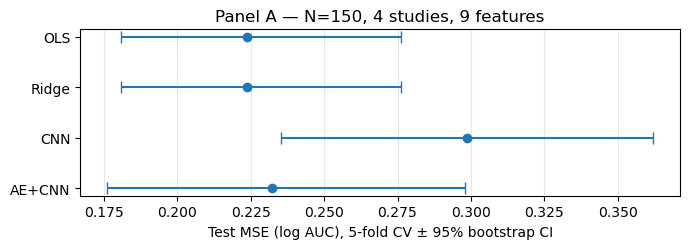

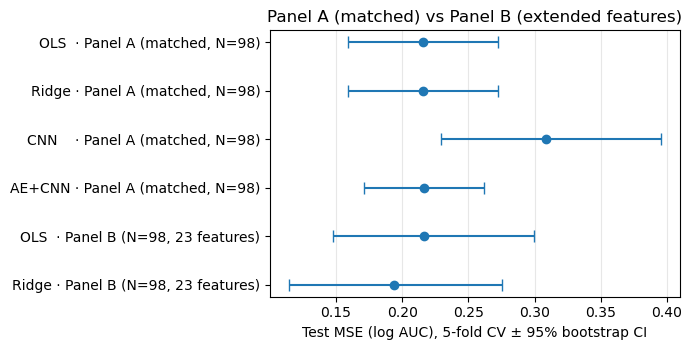

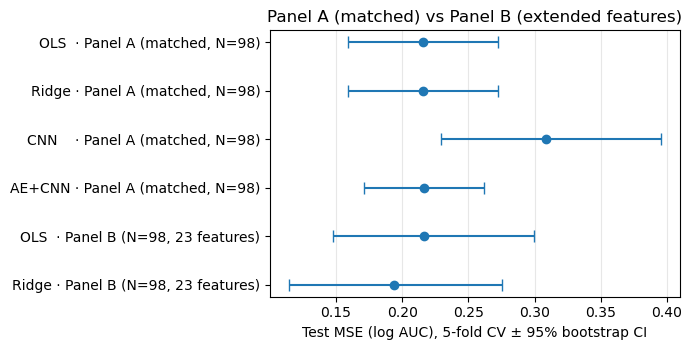

In [16]:
def forest_plot(rows, title, savepath):
    fig, ax = plt.subplots(figsize=(7, 0.6 + 0.5 * len(rows)))
    y_pos = np.arange(len(rows))[::-1]
    means = [r["mean"] for r in rows]
    los = [r["lo"] for r in rows]
    his = [r["hi"] for r in rows]
    err = [[m - lo for m, lo in zip(means, los)],
           [hi - m for hi, m in zip(his, means)]]
    ax.errorbar(means, y_pos, xerr=err, fmt="o", color="C0", capsize=4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([r["label"] for r in rows])
    ax.set_xlabel("Test MSE (log AUC), 5-fold CV ± 95% bootstrap CI")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(savepath, dpi=300)
    plt.show()
    return fig


# Panel A (4 studies, N=150)
rowsA = []
for m in ("OLS", "Ridge", "CNN", "AE+CNN"):
    mu, lo, hi = boot_ci(results_panelA[m]["fold_mse"])
    rowsA.append({"label": m, "mean": mu, "lo": lo, "hi": hi})
forest_plot(rowsA, "Panel A — N=150, 4 studies, 9 features", "figures/linear_vs_cnn_forest_panelA.pdf")

# Panel A matched + B
rowsAB = []
for name, mset, label in [
    ("OLS",   ols_aM,   "OLS  · Panel A (matched, N=98)"),
    ("Ridge", ridge_aM, "Ridge · Panel A (matched, N=98)"),
    ("CNN",    cnn_aM,   "CNN    · Panel A (matched, N=98)"),
    ("AE+CNN", aecnn_aM, "AE+CNN · Panel A (matched, N=98)"),
    ("OLS",   ols_b,    "OLS  · Panel B (N=98, 23 features)"),
    ("Ridge", ridge_b,  "Ridge · Panel B (N=98, 23 features)"),
]:
    mu, lo, hi = boot_ci(mset)
    rowsAB.append({"label": label, "mean": mu, "lo": lo, "hi": hi})
forest_plot(rowsAB, "Panel A (matched) vs Panel B (extended features)", "figures/linear_vs_cnn_forest_panelAB.pdf")


## 14. What this notebook produced

CSVs in `results/`:

- `linear_vs_cnn_local_ols.csv` — per-study OLS performance
- `linear_vs_cnn_federated_ols_coefs.csv` — federated (median) coefficients with IQR
- `linear_vs_cnn_federated_ols_eval.csv` — federated model on each study
- `linear_vs_cnn_panelA_per_fold_mse.csv` — fold-level MSE per model (Panel A)
- `linear_vs_cnn_panelA_summary.csv` — model means + 95% bootstrap CIs (Panel A)
- `linear_vs_cnn_paired_tests.csv` — Wilcoxon paired tests + Cohen's d
- `linear_vs_cnn_permutation.csv` — observed vs null MSE
- `linear_vs_cnn_sdy797_sensitivity.csv` — with vs without SDY797
- `linear_vs_cnn_panelA_vs_panelB.json` — feature-richness vs model-complexity comparison

Figures in `figures/`:

- `learning_curves.pdf`
- `residual_diagnostics.pdf`
- `linear_vs_cnn_forest_panelA.pdf`
- `linear_vs_cnn_forest_panelAB.pdf`

**AE+CNN** (CNN with autoencoder pretraining + frozen encoder) is now
included alongside OLS, Ridge, and the end-to-end CNN: it appears in
`linear_vs_cnn_panelA_summary.csv`, `linear_vs_cnn_panelA_per_fold_mse.csv`,
`linear_vs_cnn_paired_tests.csv`, `linear_vs_cnn_sdy797_sensitivity.csv`,
`linear_vs_cnn_panelA_vs_panelB.json` (Panel A matched only), and both forest
figures.
